In [9]:
import h5py
import numpy as np
from astropy import units
from IPython.display import clear_output
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
data = h5py.File("TNG100-1_subhalosCat.hdf5", 'r')

In [3]:
#get data functions with correct units
def gethubble(data):
    hubble_param = data["Header"].attrs["HubbleParam"]
    return hubble_param

def getbox_size(data):
    hubble_param = gethubble(data)
    raw_box_size = data["Header"].attrs["BoxSize"]
    box_size = (raw_box_size / hubble_param) * units.kpc
    return box_size

#position of subhalo compared to periodic box. Position is of particle with minimum gravitational potential energy.
def getsubhalo_pos(data):
    hubble_param = gethubble(data)
    raw_subhalo_pos = data["Subhalo"]["SubhaloPos"]                  #is in ckpc/h
    subhalo_pos = (raw_subhalo_pos / hubble_param) * units.kpc
    return subhalo_pos

#cm of each subhalo, determined with all types of particles.
def getsubhalo_cm(data):
    hubble_param = gethubble(data)
    raw_subhalo_cm = data["Subhalo"]["SubhaloCM"]                    #is in ckpc/h
    subhalo_cm = (raw_subhalo_cm / hubble_param) * units.kpc
    return subhalo_cm

#total mass of all particles of subhalo. subhalo's of a subhalo not included in mass.
def getsubhalo_mass(data):
    hubble_param = gethubble(data)
    raw_subhalo_mass = data["Subhalo"]["SubhaloMass"]                #is in 10**10 solmass/h
    subhalo_mass = (raw_subhalo_mass*1e10/hubble_param) * units.Msun
    return subhalo_mass

#total mass of subhalo by particle type. 
def getsubhalo_massbytype(data):
    hubble_param = gethubble(data)
    raw_subhalo_massbytype = np.array(data["Subhalo"]["SubhaloMassType"])      #is in 10**10 solmass/h
    subhalo_massbytype = (raw_subhalo_massbytype*1e10/hubble_param) * units.Msun
    #Nx6, [Gas, DM, UNUSED, Tracers, Stars/wind particles, Black holes]
    return subhalo_massbytype

In [4]:
#boolean numpy array stating if a subhalo at that index contains a galaxy. 
def getgalaxy_mask(data):
    total_mass = getsubhalo_massbytype(data)
    stellar_mass = total_mass[:,4]

    mask = (stellar_mass > 0.0)
    return mask

def getgalaxy_cm(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_cm = getsubhalo_cm(data)
    galaxy_cm = subhalo_cm[galaxy_mask, :]
    return galaxy_cm

In [109]:
def minimal_distance(pos1, pos2, boxsize):
    displacement = pos1 - pos2
    #see minimal image convention
    displacement -= boxsize*np.round(displacement / boxsize)
    return np.linalg.norm(displacement, axis=1)

#source: https://stackoverflow.com/questions/11339210/how-to-get-integer-values-from-a-string-in-python
def getint_from_string(string):
    integer = int(''.join(filter(str.isdigit, string)))
    return integer
 
def calcDD(data, nr_bins=100, binmode="linear"):
    galaxy_cm = getgalaxy_cm(data)
    nr_galaxies = len(galaxy_cm)
    boxsize = getbox_size(data)

    #nr_bins-1, because bins are the bin_edges
    DD = np.zeros(nr_bins-1)
    
    bins = np.linspace(0.0, boxsize/2, nr_bins)
    if(binmode == "logarithmic"):
        bins = np.logspace(np.log10(0.0), np.log10(boxsize.value/2), nr_bins) * boxsize.unit

    for i in range(nr_galaxies):
        print(f"Bins are {binmode}, Progress: {i/(nr_galaxies-1)*100:.2f}%")
        clear_output(wait=True) 
        
        galaxy_i = galaxy_cm[i]
        galaxies_i = np.empty([nr_galaxies-1, galaxy_i.shape[0]])*units.kpc
        galaxies_i[:] = galaxy_i
        galaxies_other = np.delete(galaxy_cm, i, 0)
        
        dist = minimal_distance(galaxies_i, galaxies_other, boxsize)
        hist, bins = np.histogram(dist, bins=bins)
        DD += hist

    #all galaxy distances were double counted for ease of programming, simply divide by two
    DD = DD/2
    DD_filename = "DD_" + str(nr_bins) + "bins_" + binmode
    print("done")
    print("Filename: " + DD_filename)
    print("DD: " + str(DD))
    np.save(DD_filename, DD)

#https://arxiv.org/pdf/astro-ph/9912088
def two_point_correlation(data, DD_filename):
    nr_bins = getint_from_string(DD_filename)
    galaxy_cm = getgalaxy_cm(data)
    nr_galaxies = len(galaxy_cm)
    boxsize = getbox_size(data)

    DD_unnormalized = np.load(DD_filename)
    DD = DD_unnormalized / (sum(DD_unnormalized))

    bins = np.linspace(0.0, boxsize/2, nr_bins)
    if "logarithmic" in DD_filename:
        bins = np.logspace(np.log10(0.0), np.log10(boxsize.value/2), nr_bins) * boxsize.unit

    #-----------------------------CALCULATE RR------------------------------------------
    #RR(r)=ρ4πr2dr, dr = bin width, r=middle of bin
    boxvolume = boxsize**3
    galaxies_per_volume = nr_galaxies/boxvolume

    bin_inner_bound = bins[:-1]         
    bin_outer_bound = bins[1:]       
    bin_centre = (bin_inner_bound + bin_outer_bound) / 2  

    dr = bin_outer_bound - bin_inner_bound
    bin_volume = 4*np.pi*(bin_centre**2)*dr

    #this is from the point of view of 1 galaxy at r=0, what is the probability of it having a pair with another galaxy in a bin?
    # nr_point_pairs: n(n-1)/2
    nr_point_pairs = nr_galaxies*(nr_galaxies-1)/2
    expected_pairs_per_bin = bin_volume*galaxies_per_volume
    RR = (expected_pairs_per_bin/nr_point_pairs)*nr_galaxies
    #sum of RR is almost 1, but correct the floating point error
    RR = RR/sum(RR)

    #natural estimator
    two_point_correlation = DD/RR - 1.0
        
    return two_point_correlation, bin_centre
        

Uncomment the following line to calculate DD. Warning: takes about 3 hours!

In [ ]:
#calcDD(data, nr_bins=100, binmode="logarithmic")

In [155]:
def expected_autocorr_powerlaw(radius, amplitude):
    return amplitude*(radius**-1.8)

def expected_autocorr_powerlaw_log(radius_log, amplitude):
    radius = 10**radius_log
    return np.log10(amplitude*(radius**-1.8))

def fit_expected_autocorr_powerlaw(data, DD_filename="DD_100bins_linear.npy", r_cutoff = 15*units.Mpc):
    two_point_corr, bin_center = two_point_correlation(data=data, DD_filename=DD_filename)
    bin_center = bin_center.to("Mpc")
    amp_estimate = 35

    #apply cutoff, because values higher than it are sparse, resulting in edge artifact
    
    bin_center = bin_center[bin_center<=r_cutoff]
    two_point_corr = two_point_corr[:len(bin_center)]

    bin_center_log = np.log10(bin_center.value)
    two_point_corr_log = np.log10(two_point_corr)
    
    #------------------------------------------FIT---------------------------------------------
    popt, pcov = curve_fit(expected_autocorr_powerlaw_log, bin_center_log, two_point_corr_log, p0=amp_estimate)
    parameter_fit = popt[0]
    print(f"Amplitude fit = {parameter_fit}")
    print(f"Amplitude std = {pcov[0]}")

    #------------------------------------------ERRORS------------------------------------------
    fit_corr_log = expected_autocorr_powerlaw_log(bin_center_log, parameter_fit)
    residuals = two_point_corr_log - fit_corr_log     
    rms_error = np.sqrt(np.mean(residuals**2))                          
    
    squaresum_residual = np.sum(residuals**2)
    squaresum_total = np.sum((two_point_corr_log - np.mean(two_point_corr_log))**2)
    rsquared_error = 1.0 - (squaresum_residual / squaresum_total)            #relative error

    print("RMSE of fit: " + str(rms_error))
    print("RSQUARED of fit: " + str(rsquared_error))   #RSQUARED of 1 is best.

    #------------------------------------------PLOT--------------------------------------------
    plt.scatter(bin_center, two_point_corr, s=1, label="Data", c="blue")
    plt.plot(bin_center, expected_autocorr_powerlaw(bin_center, parameter_fit), alpha=0.5, label="$R^{-1.8}$ fit", c="red")
    plt.xlabel(f"R({bin_center.unit})")
    plt.ylabel("ξ(R)")

    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.title(f"Two point correlation fit with Rcutoff={r_cutoff}")
    plt.show()

Amplitude fit = 34.296629127925925
Amplitude std = [0.85580932]
RMSE of fit: 0.059732138211944355
RSQUARED of fit: 0.9933188949491395


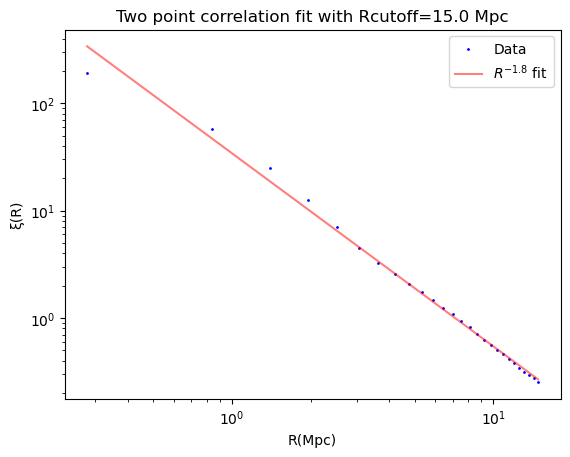

In [162]:
fit_expected_autocorr_powerlaw(data, DD_filename="DD_100bins_linear.npy", r_cutoff=15*units.Mpc)

Amplitude fit = 32.0142893405132
Amplitude std = [0.90941897]
RMSE of fit: 0.0765350445758365
RSQUARED of fit: 0.9901457463269464


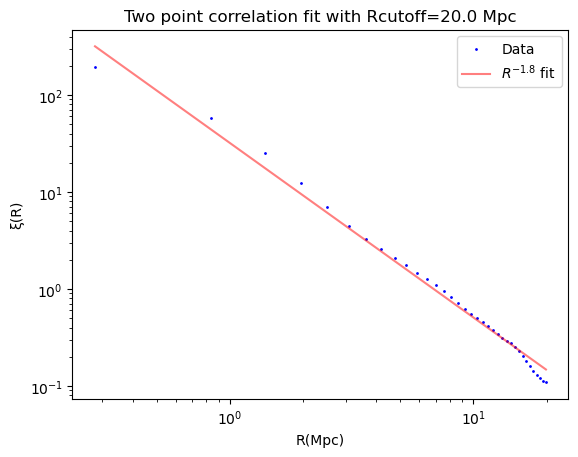

In [163]:
fit_expected_autocorr_powerlaw(data, DD_filename="DD_100bins_linear.npy", r_cutoff=20*units.Mpc)

Amplitude fit = 29.294658919823053
Amplitude std = [1.19418403]
RMSE of fit: 0.10746272118367474
RSQUARED of fit: 0.9824278554362099


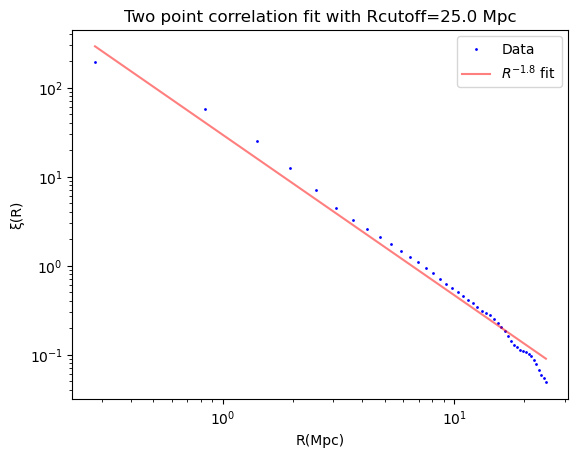

In [164]:
fit_expected_autocorr_powerlaw(data, DD_filename="DD_100bins_linear.npy", r_cutoff=25*units.Mpc)

In [158]:
def plot_two_point_correlation(data, DD_filename="DD_100bins_linear.npy"):
    boxsize = getbox_size(data)
    half_boxsize = boxsize.to("Mpc")/2
    fit_amplitude = 34.296629127925925
    
    two_point_corr, bin_center = two_point_correlation(data=data, DD_filename=DD_filename)
    plt.scatter(bin_center.to("Mpc"), two_point_corr, s=2, c="blue", label="Data")
    plt.plot(bin_center.to("Mpc"), (fit_amplitude*bin_center.to("Mpc")**(-1.8)), c="red", label="$R^{-1.8}$ fit", alpha=0.6)
    #plt.axvline(x = half_boxsize.value, color = 'green', label = "Half periodic box")

    plt.title("Two point correlation function of simulated galaxies")
    plt.yscale("log")
    plt.xscale("log")
    plt.xlabel("R(" + str(bin_center.to("Mpc").unit) + ")")
    plt.ylabel("ξ(R)")
    plt.legend()
    plt.show()

Plot follows a powerlaw $R^{-1.8}$ up until 15 Mpc, which is in good agreement with observations and other simulations. As seen in lecture 10, slide 19: "Comparison of simulated and observed galaxy two point correlation funcion (TPCF) is in very good agreement, approximated by a power-law behaviour for scales up to about 30 Mpc"

Sharp dropoff for final 2 points is most likely an artifact, there are very few galaxies at such long distances compared to the increasing volume.

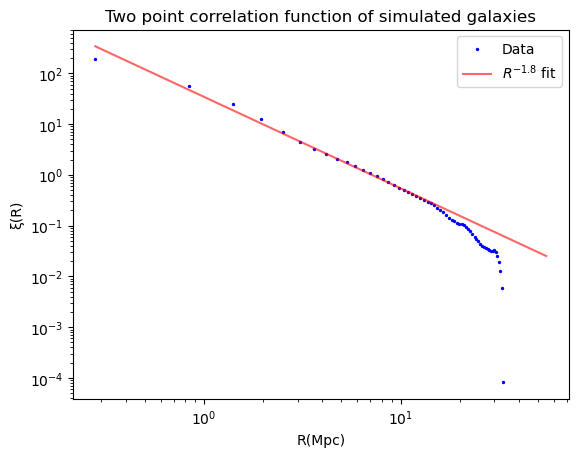

In [154]:
plot_two_point_correlation(data)